<div style="background-color: #f0f4ff; padding: 16px 20px; border-left: 5px solid #4a6fa5; border-radius: 4px;">
<h2 style="margin: 0 0 8px 0;">Lab 3: Image Recognition</h2>
<p style="margin: 0 0 16px 0; font-size: 13px; color: #555;">Adapted from Chan, Yee Kit, Erica Lai, and Yu Chen. "Teaching Tip: Teaching Undergraduate IS Students Hands-on Generative AI Development Skills." <em>Journal of Information Systems Education</em> 37(1), 2026.</p>
<hr style="border: none; border-top: 1px solid #ccc; margin-bottom: 16px;">
<b>First time in a coding environment?</b> You do not need to write any code — just run it and read the output. Click the play button or press <b>Shift + Enter</b>. Go top to bottom. If something breaks, go to <b>Runtime → Restart and run all</b>.<br><br>
<b>Table of contents</b> — Click the list icon on the left sidebar to jump between sections.<br>
<b>Two cell types</b> — Code cells have a play button. Text cells (like this one) have instructions.<br>
<b>Run order matters</b> — Skipping a cell may cause errors in later ones.
</div>

<div>
<h3>What is Image Recognition?</h3>

<p>In Labs 1 and 2, the AI read text — a prompt, a resident message. The input was always words.</p>

<p>A resident sees illegal dumping on their street. To report it they need to open an app, find the right category, type a description, add a location. Most don't bother. The city never finds out.</p>

<p>Image Recognition means the AI can read images the same way it reads text. You upload a photo and the AI identifies the problem, rates the urgency, and names the city department that should respond — automatically.</p>

<p><strong>Labs 1–3 progression:</strong></p>
<table style="border-collapse:collapse;">
  <tbody>
    <tr style="background-color:#fafafa;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 1</td><td style="border:1px solid #ccc; padding:8px 16px;">AI responds to prompts — and you control how</td></tr>
    <tr><td style="border:1px solid #ccc; padding:8px 16px;">Lab 2</td><td style="border:1px solid #ccc; padding:8px 16px;">AI extracts structured data from messy text</td></tr>
    <tr style="background-color:#f0f4ff; font-weight:bold;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 3 ← you are here</td><td style="border:1px solid #ccc; padding:8px 16px;">AI reads images and generates civic reports</td></tr>
  </tbody>
</table>
</div>

# Setting Up Your Development Environment
- Install the required libraries.

In [ ]:
!pip install -q google-generativeai Pillow

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


# Part 1: Upload Your Image

You need an image to analyze. Choose one of these options:

- **Option A** — Take a photo on your phone and upload it here.
- **Option B** — Use any existing image from your computer or downloaded from the internet.
- **Option C (recommended)** — Photograph something in your neighborhood that you believe represents a real civic or social issue. This could be a pothole, graffiti, overgrown vegetation blocking a sign, poor lighting on a path, a broken bench in a park — anything you personally think is a problem.

Supported formats: jpg, jpeg, png, gif, webp — maximum 20 MB.

> **Why Option C?** The reflection at the end of this lab asks you to compare what *you* see in the image to what the *AI* sees. Choosing a real issue you care about makes that comparison meaningful.

Saving download (2).png to download (2).png
Uploaded: download (2).png
Image size: 512x338 pixels


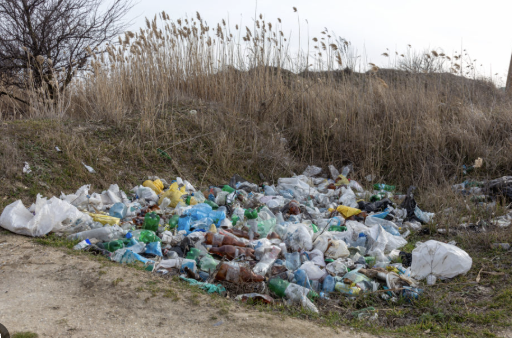

In [9]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

# Part 2: Core Analysis Function

This function sends both the image and a question to Gemini.
This is called **multimodal input** — the model processes image and text together.

Run this cell to define the function. No output yet — that comes in Part 3.

In [11]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


# Part 3: Four Standard Civic Analysis Questions

San Jose's 311 system triages every report using four key questions:

1. What is the problem?
2. What are the public health or safety implications?
3. How urgent is this?
4. Which department or service should respond?

Run the cell below to see how Gemini answers all four for your image.
This may take up to two minutes due to rate limits — that is expected.

In [12]:
civic_questions = [
    ("PROBLEM",  "Describe the civic or environmental problem visible in this image. Be specific about what you see."),
    ("IMPACT",   "What are the public health, safety, or community impacts of what is shown in this image?"),
    ("URGENCY",  "Rate the urgency of this situation as LOW, MEDIUM, or HIGH. Explain your rating in 2–3 sentences."),
    ("ACTION",   "Which specific city department or service should respond to this? What action should they take?")
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The primary civic and environmental problem visible in this image is **illegal dumping and severe plastic pollution**.

Specifically, I see:

1.  **Massive Accumulation of Plastic Waste:** A very large, sprawling pile of garbage, predominantly plastic, covers a significant portion of the lower-mid foreground, extending from what appears to be a dirt path up into a grassy embankment.
2.  **Types of Waste:** The vast majority of the visible waste consists of discarded plastic bottles of various sizes and colors (clear, blue, green, yellow, brown), suggesting beverages like water, soda, and juice. There are also numerous plastic bags, some white and crumpled, others darker, scattered throughout the pile.
3.  **Location:** The dumping has occurred in an undeveloped or neglected natural area. The background features a steep bank covered in dry, tall reeds or grasses, with some bare trees visible further to the left. This is clearly not a designated waste disposal site.
4.  *

# Part 4: Ask Your Own Question

Now that you have seen the standard four-question analysis, ask the model something specific
that is relevant to your own image or your team's project scenario.

Examples:
- `"Is there any graffiti or vandalism visible in this image?"`
- `"Does this sidewalk appear to be in need of repair?"`
- `"Are there any accessibility barriers visible for wheelchair users?"`
- `"What time of day does this appear to have been taken?"`
- `"What would it cost to fix what you see here?"`

In [13]:
custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: Is there any graffiti or vandalism visible in this image?

--- Response ---
No, there is no graffiti or vandalism visible in this image.

The image clearly shows a significant amount of litter, primarily plastic bottles and bags, which represents pollution and neglect. However, there are no visible markings (graffiti) or deliberate damage to structures or property (vandalism) in the scene.

Tokens used: 1264


# Part 5: Reflection — What the AI Sees vs. What You See

**Write your answers directly in this text cell. Double-click to edit it.**

This is the most important part of the lab. Read your AI outputs carefully before answering.

---

**Question 1 — Comparison:**
Look at the AI's PROBLEM and URGENCY answers.
Do they match your own assessment of the image?
Describe at least one specific thing the AI got right and one thing it missed or misjudged.

*Your answer here:* The description of the problem was quite accurate. It was able to perfectly identify the illegal dumping that was conducted, the large amount of plastic bottles and other trash, as well as describe the surrounding environment. This precisely matches what i saw in the provided image. However, the AI was wrong to set the urgency to medium. Even though it recognized and flagged the fire and physical hazards, it still rated the image as moderately urgent rather than high.
---

**Question 2 — What the model was trained to see:**
The AI's analysis reflects patterns from its training data.
If you photographed something that is a real problem in your community but
looks ordinary (for example, a sidewalk that has never had curb cuts for wheelchair users),
would the AI recognize it as a problem? What does this tell you about whose problems
get encoded into AI systems — and whose don't?

*Your answer here:*
The AI was able to excellently distinguish the illegal dumping in the provided photo due to the image having lots of color and neutral background. However, if I had taken a photo of a sidewalk that has never had curb cuts installed, the AI probably would have just classified it as a regular sidewalk. Unless, the AI has been specifically trained, the absence of an accessibility feature doesn't look like a problem. AI image models recognize problems that look like garbage and typically miss problems that look like nothing. The effect of minimal training of AI image models usually results in communities whose problems take the form of what is under the surface being completely overlooked.

---

**Question 3 — Deployment decision:**
Imagine this system is deployed: a resident uploads a photo to the San Jose 311 app,
the AI analyzes it automatically, and a work order is generated without any human review.
For what types of images or issues would this work well?
For what types would automated routing be a mistake?
Who should make that call, and how?

*Your answer here:*
Automatically routing complaints makes sense when a situation is simple. One obvious thing in the image is that there is no person in the frame. However the problems starts when conditions break. If a person is visible in the photo and the AI listed five different possible departments instead of picking one like it did with the provided image then it would show a sign that the system is unsure and a human should take a look. The image had exactly that issue. The AI listed fire risks but still rated the situation under medium urgency. This kind of decision should sit with the 311 director and the city's privacy office but not the engineering team. The reasoning here is that the people most likely to be harmed by a bad call are usually not the same people building the system. In my opinion, if a person is in the frame, or if the AI is hedging on the department, the photo should go to a human reviewer prior to any work order being created.